In [3]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted successfully!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!


In [4]:
!pip install -q pynwb          # For reading .nwb files
!pip install -q scikit-learn   # Ridge regression
!pip install -q scipy          # Pearson r

print('All packages installed.')

All packages installed.


In [5]:
import os
import re
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn import linear_model
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

print('J. Robert Oppenheimer: “Now I am become Death, the destroyer of worlds.”')

J. Robert Oppenheimer: “Now I am become Death, the destroyer of worlds.”


In [6]:
def extract_dates_from_filenames(data_path: str) -> list:

    files = os.listdir(data_path)
    dates = set()
    for f in files:
        if f.endswith('.pkl'):
            stem = f.replace('.pkl', '')
            match = re.match(r'^(.+?)_(CO|RD)$', stem, re.IGNORECASE)  # Handles patterns like  YYYY-MM-DD_CO  or  YYYY-MM-DD_RD
            if match:
                dates.add(match.group(1))
            else:
                dates.add(stem)
    return sorted(dates)


def load_day(date: str, data_path: str):

    data_CO, data_RD = None, None

    co_path = os.path.join(data_path, f'{date}_CO.pkl')
    rd_path = os.path.join(data_path, f'{date}_RD.pkl')

    if os.path.exists(co_path):  #Centre out file sessions
        with open(co_path, 'rb') as f:
            data_CO = pickle.load(f)
        print(f'  Loaded CO: {co_path}')
    else:
        print(f'  [INFO] No CO file found for date {date}')

    if os.path.exists(rd_path): #Load Random file sessions
        with open(rd_path, 'rb') as f:
            data_RD = pickle.load(f)
        print(f'  Loaded RD: {rd_path}')
    else:
        print(f'  [INFO] No RD file found for date {date}')

    return data_CO, data_RD


print('Hi MOnkey N')

Hi MOnkey N


In [7]:

nwb_folder = '/content/drive/My Drive/LINK_dataset/raw_nwb'
pkl_folder  = '/content/drive/My Drive/LINK_dataset/pkl_files'

# Verify the folder exists
assert os.path.isdir(pkl_folder), f'PKL folder not found: {pkl_folder}'

# Extract all available recording dates from PKL filenames
dates = extract_dates_from_filenames(pkl_folder)

print(f'Found {len(dates)} recording dates.')
print('First 5:', dates[:5])
print('Last  5:', dates[-5:])

Found 312 recording dates.
First 5: ['sub-Monkey-N_ses-20200127_ecephys', 'sub-Monkey-N_ses-20200130_ecephys', 'sub-Monkey-N_ses-20200204_ecephys', 'sub-Monkey-N_ses-20200205_ecephys', 'sub-Monkey-N_ses-20200206_ecephys']
Last  5: ['sub-Monkey-N_ses-20230616_ecephys', 'sub-Monkey-N_ses-20230619_ecephys', 'sub-Monkey-N_ses-20230620_ecephys', 'sub-Monkey-N_ses-20230621_ecephys', 'sub-Monkey-N_ses-20230622_ecephys']


In [8]:
import os
import pickle
import numpy as np
from sklearn.linear_model import Ridge
from scipy.stats import pearsonr

def run_brute_force_decoder(pkl_path):
    # 1. Get every single .pkl file in the folder
    all_files = [f for f in os.listdir(pkl_path) if f.endswith('.pkl')]

    if not all_files:
        print(f"CRITICAL: No .pkl files found in {pkl_path}. Check your path!")
        return None

    print(f"Found {len(all_files)} total .pkl files. Testing first valid file...")

    for file_name in all_files:
        full_path = os.path.join(pkl_path, file_name)

        try:
            with open(full_path, 'rb') as f:
                data = pickle.load(f)

            # Check if this specific file has the data we need
            if isinstance(data, dict) and 'sbp' in data and 'finger_kinematics' in data:
                print(f"\nSuccessfully loaded: {file_name}")

                X = data['sbp']
                y = data['finger_kinematics']

                # Basic validation of shapes
                if X.shape[0] != y.shape[0]:
                    print(f"  [Skip] Row mismatch: SBP={X.shape[0]}, Kinematics={y.shape[0]}")
                    continue

                # --- DECODING ---
                split = int(0.8 * len(X))
                X_train, X_test = X[:split], X[split:]
                y_train, y_test = y[:split], y[split:]

                model = Ridge(alpha=100.0)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)

                # Calculate Pearson r
                corrs = [pearsonr(y_test[:, i], y_pred[:, i])[0] for i in range(y.shape[1])]

                print(f"  [SUCCESS] Mean Pearson r: {np.mean(corrs):.4f}")
                return y_test, y_pred, file_name

            else:
                # If the file loaded but didn't have the right keys
                continue

        except Exception as e:
            print(f"  [Error] Could not read {file_name}: {e}")
            continue

    print("Checked all files, but none contained both 'sbp' and 'finger_kinematics'.")
    return None

# --- EXECUTION ---
result = run_brute_force_decoder(pkl_folder)

if result:
    y_true, y_pred, session_name = result
    print(f"\nFinal outcome: Ready to plot results for {session_name}")
else:
    print("\nPipeline failed to find processable data.")

Found 312 total .pkl files. Testing first valid file...

Successfully loaded: sub-Monkey-N_ses-20200127_ecephys.pkl
  [SUCCESS] Mean Pearson r: 0.3876

Final outcome: Ready to plot results for sub-Monkey-N_ses-20200127_ecephys.pkl


In [9]:
import pynwb
import numpy as np
import pickle
import os

nwb_folder = '/content/drive/My Drive/LINK_dataset/raw_nwb'
pkl_folder  = '/content/drive/My Drive/LINK_dataset/pkl_files'
os.makedirs(pkl_folder, exist_ok=True)

nwb_files = sorted([f for f in os.listdir(nwb_folder) if f.endswith('.nwb')])
total = len(nwb_files)
done = 0
failed = []
for i, filename in enumerate(nwb_files):
    nwb_path = os.path.join(nwb_folder, filename)
    pkl_path  = os.path.join(pkl_folder, filename.replace('.nwb', '.pkl'))

    if os.path.exists(pkl_path):
        print(f"[{i+1}/{total}] Already done — skipping")
        done += 1
        continue

    try:
        io  = pynwb.NWBHDF5IO(nwb_path, 'r')
        nwb = io.read()


        sbp      = nwb.analysis['SpikingBandPower'].data[:]    # (N, 96) brain signals
        tcr      = nwb.analysis['ThresholdCrossings'].data[:]  # (N, 96) spike counts
        idx_pos  = nwb.analysis['index_position'].data[:]      # (N,)    index finger position
        mrs_pos  = nwb.analysis['mrs_position'].data[:]        # (N,)    MRP finger position
        idx_vel  = nwb.analysis['index_velocity'].data[:]      # (N,)    index finger velocity
        mrs_vel  = nwb.analysis['mrs_velocity'].data[:]        # (N,)    MRP finger velocity
        time     = nwb.analysis['SpikingBandPower'].timestamps[:]  # (N,) timestamps

        io.close()

        # Stack fingers into one clean array: (N, 4)
        finger_kinematics = np.column_stack([idx_pos, mrs_pos, idx_vel, mrs_vel])

        data = {
            'sbp'               : sbp,               # brain signal (SBP)
            'tcr'               : tcr,               # brain signal (spike counts)
            'finger_kinematics' : finger_kinematics, # [index_pos, mrs_pos, index_vel, mrs_vel]
            'time'              : time,              # timestamps
            'filename'          : filename           # which day this is
        }

        with open(pkl_path, 'wb') as f:
            pickle.dump(data, f)

        done += 1
        print(f"[{i+1}/{total}] Converted: {filename}  sbp:{sbp.shape}  fingers:{finger_kinematics.shape}")

    except Exception as e:
        print(f"[{i+1}/{total}] FAILED: {e}")
        failed.append(filename)


print(f"Converted : {done}/{total}")
print(f"Failed    : {len(failed)}")
if failed:
    for f in failed: print("  ", f)

[1/312] Already done — skipping
[2/312] Already done — skipping
[3/312] Already done — skipping
[4/312] Already done — skipping
[5/312] Already done — skipping
[6/312] Already done — skipping
[7/312] Already done — skipping
[8/312] Already done — skipping
[9/312] Already done — skipping
[10/312] Already done — skipping
[11/312] Already done — skipping
[12/312] Already done — skipping
[13/312] Already done — skipping
[14/312] Already done — skipping
[15/312] Already done — skipping
[16/312] Already done — skipping
[17/312] Already done — skipping
[18/312] Already done — skipping
[19/312] Already done — skipping
[20/312] Already done — skipping
[21/312] Already done — skipping
[22/312] Already done — skipping
[23/312] Already done — skipping
[24/312] Already done — skipping
[25/312] Already done — skipping
[26/312] Already done — skipping
[27/312] Already done — skipping
[28/312] Already done — skipping
[29/312] Already done — skipping
[30/312] Already done — skipping
[31/312] Already do

We load day index 42, merge CO + RD sessions (if both exist), split into
train / test sets by trial index, and add a temporal history window to the
neural features (i.e., the decoder can look back 20 time-steps).

In [10]:
!ls "/content/drive/My Drive/LINK_dataset/pkl_files" | head -n 20

sub-Monkey-N_ses-20200127_ecephys.pkl
sub-Monkey-N_ses-20200130_ecephys.pkl
sub-Monkey-N_ses-20200204_ecephys.pkl
sub-Monkey-N_ses-20200205_ecephys.pkl
sub-Monkey-N_ses-20200206_ecephys.pkl
sub-Monkey-N_ses-20200211_ecephys.pkl
sub-Monkey-N_ses-20200222_ecephys.pkl
sub-Monkey-N_ses-20200224_ecephys.pkl
sub-Monkey-N_ses-20200225_ecephys.pkl
sub-Monkey-N_ses-20200228_ecephys.pkl
sub-Monkey-N_ses-20200302_ecephys.pkl
sub-Monkey-N_ses-20200310_ecephys.pkl
sub-Monkey-N_ses-20200313_ecephys.pkl
sub-Monkey-N_ses-20200317_ecephys.pkl
sub-Monkey-N_ses-20200318_ecephys.pkl
sub-Monkey-N_ses-20200319_ecephys.pkl
sub-Monkey-N_ses-20200320_ecephys.pkl
sub-Monkey-N_ses-20200626_ecephys.pkl
sub-Monkey-N_ses-20200708_ecephys.pkl
sub-Monkey-N_ses-20200714_ecephys.pkl


In [11]:
class DataTools:
    def extract_dates_from_filenames(self, data_path):
        files = [f for f in os.listdir(data_path) if f.endswith('.pkl')]
        return sorted([f.replace('.pkl', '') for f in files])

    def load_day(self, session_name, data_path):
        file_path = os.path.join(data_path, f"{session_name}.pkl")
        if os.path.exists(file_path):
            with open(file_path, 'rb') as f:
                data = pickle.load(f)
            return data, None
        return None, None


data_tools = DataTools()

data_path = pkl_folder
dates = data_tools.extract_dates_from_filenames(data_path)
data_CO, data_RD = data_tools.load_day(dates[0], data_path)

print(f"Data Exist in CO: {True if data_CO is not None else False} RD: {True if data_RD is not None else False}")

Data Exist in CO: True RD: False


In [15]:
if data_CO and isinstance(data_CO, dict):
    print("data_CO keys:", data_CO.keys())
else:
    print("data_CO has no keys or is None")

if data_RD and isinstance(data_RD, dict):
    print("data_RD keys:", data_RD.keys())
else:
    print("data_RD has no keys or is None")

data_CO keys: dict_keys(['sbp', 'tcr', 'finger_kinematics', 'time', 'filename'])
data_RD has no keys or is None


In [16]:
import sys
import os
import pickle
import numpy as np
import pandas as pd
from sklearn import linear_model
from scipy.stats import pearsonr

data_path = '/content/drive/My Drive/LINK_dataset/pkl_files'

files = [f for f in os.listdir(data_path) if f.endswith('.pkl')]
dates = sorted([f.replace('.pkl', '') for f in files])

def load_day_custom(session_name, data_path):
    file_path = os.path.join(data_path, f"{session_name}.pkl")
    if os.path.exists(file_path):
        with open(file_path, 'rb') as f:
            return pickle.load(f)
    return None
date = dates[42]
data = load_day_custom(date, data_path)

print(f"Loaded session: {date}")

Loaded session: sub-Monkey-N_ses-20201212_ecephys


In [17]:
sbp = data['sbp']
beh = data['finger_kinematics']
split_idx = int(0.8 * len(sbp))

neural_train = sbp[:split_idx]
neural_test  = sbp[split_idx:]
finger_train = beh[:split_idx]
finger_test  = beh[split_idx:]
def add_hist(X, Y, hist=10):
    nNeu = X.shape[1]
    adjX = np.zeros((X.shape[0]-hist, nNeu, (hist+1)))
    for h in range(hist+1):
        adjX[:,:,h] = X[h:X.shape[0]-hist+h,:]
    adjY = Y[hist:,:]
    adjX = adjX.reshape(adjX.shape[0],-1)
    return adjX, adjY
neural_train, finger_train = add_hist(neural_train, finger_train, hist=20)
neural_test, finger_test   = add_hist(neural_test, finger_test, hist=20)
neural_train = np.concatenate((neural_train, np.ones((len(neural_train), 1))), axis=1)
neural_test  = np.concatenate((neural_test, np.ones((len(neural_test), 1))), axis=1)

print(f"Augmented Feature Shape: {neural_train.shape}")

Augmented Feature Shape: (28182, 2017)


In [18]:
reg = linear_model.Ridge(alpha=0.001, fit_intercept=False)
reg.fit(neural_train, finger_train)

# Predict
rr_prediction = reg.predict(neural_test)

# Compute Pearson r for each output dimension
r_values = np.array([pearsonr(finger_test[:, i], rr_prediction[:, i])[0] for i in range(finger_test.shape[1])])

print("-" * 30)
print(f"Pearson r for each output dimension: {r_values}")
print(f"Mean Correlation: {np.mean(r_values):.4f}")
print("-" * 30)

------------------------------
Pearson r for each output dimension: [0.74727789 0.6787137  0.44332155 0.44410423]
Mean Correlation: 0.5784
------------------------------


**Train on day 42 on Ridge Regression**

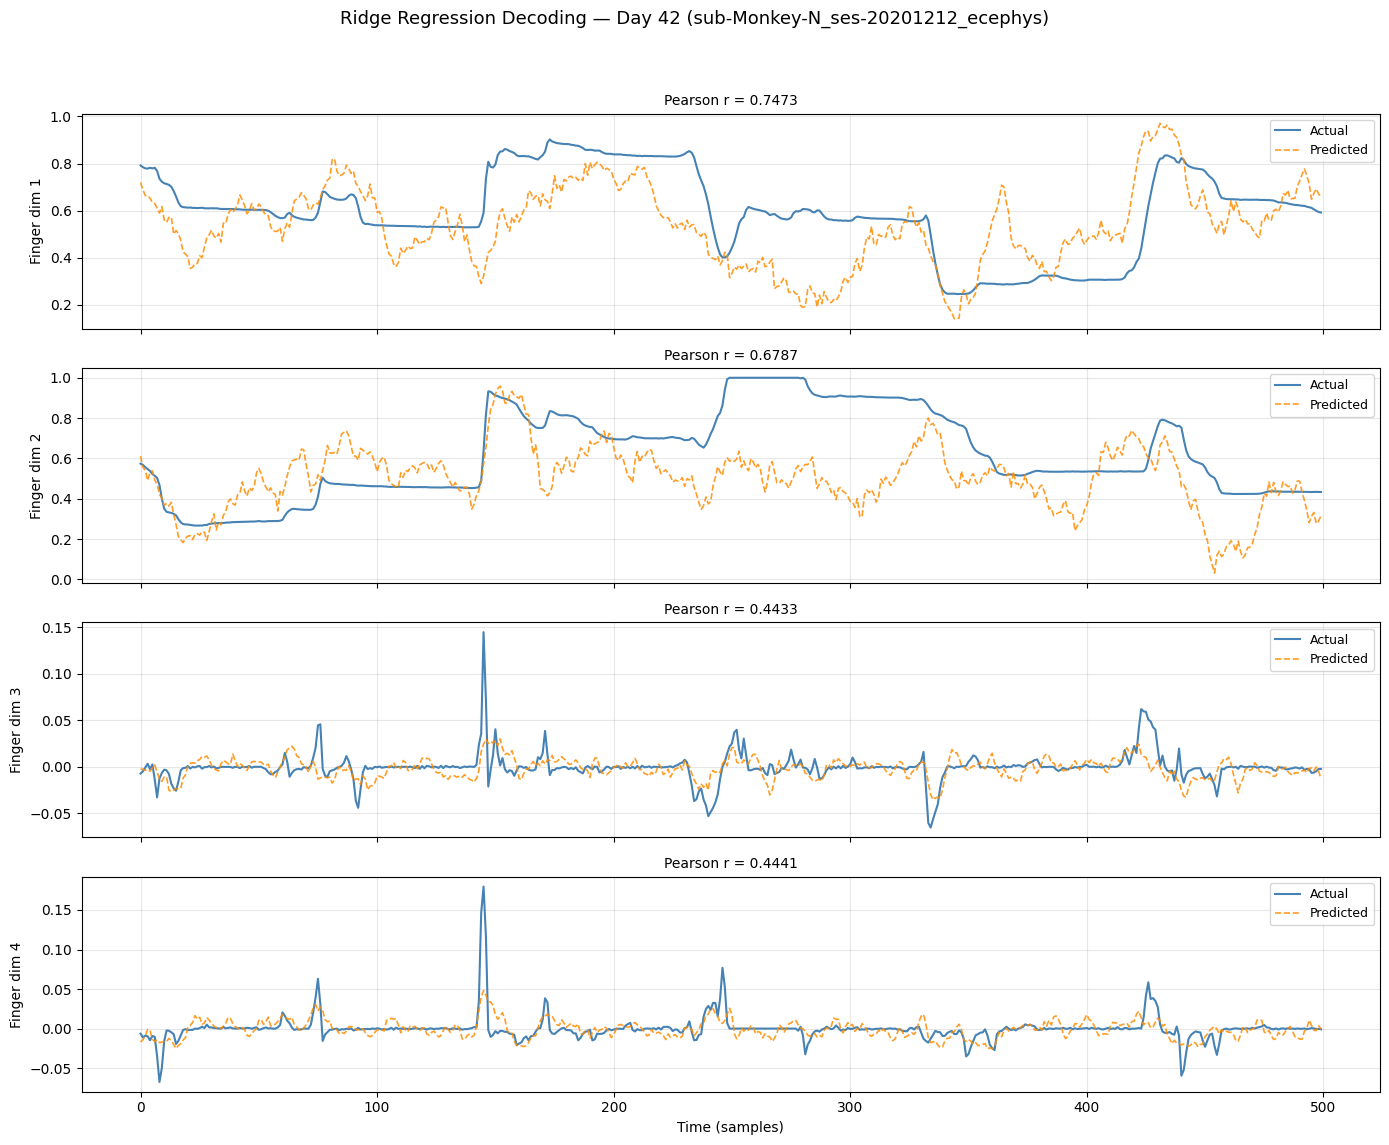

Plot saved to /content/ridge_regression_decoding.png


In [19]:
DAY_INDEX = 42
n_dims = finger_test.shape[1]
n_show = 500   # First 500 samples
t = np.arange(n_show)

fig, axes = plt.subplots(n_dims, 1, figsize=(14, 3 * n_dims), sharex=True)
fig.suptitle(f'Ridge Regression Decoding — Day {DAY_INDEX} ({dates[DAY_INDEX]})', fontsize=13)

for i, ax in enumerate(axes):
    ax.plot(t, finger_test[:n_show, i],   color='steelblue', lw=1.5, label='Actual')
    ax.plot(t, rr_prediction[:n_show, i], color='darkorange', lw=1.2, alpha=0.85, label='Predicted', linestyle='--')
    ax.set_ylabel(f'Finger dim {i+1}', fontsize=10)
    ax.set_title(f'Pearson r = {r_values[i]:.4f}', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (samples)', fontsize=10)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('/content/ridge_regression_decoding.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to /content/ridge_regression_decoding.png')

**Ridge Regression Same day stability**

Session 0/312 | r: 0.6480
Session 20/312 | r: 0.6143
Session 40/312 | r: 0.6367
Session 60/312 | r: 0.5765
Session 80/312 | r: 0.6364
Session 100/312 | r: 0.6029
Session 120/312 | r: 0.5485
Session 140/312 | r: 0.5910
Session 160/312 | r: 0.6229
Session 180/312 | r: 0.6547
Session 200/312 | r: 0.5722
Session 220/312 | r: 0.6979
Session 240/312 | r: 0.6672
Session 260/312 | r: 0.6700
Session 280/312 | r: 0.5560
Session 300/312 | r: 0.6008


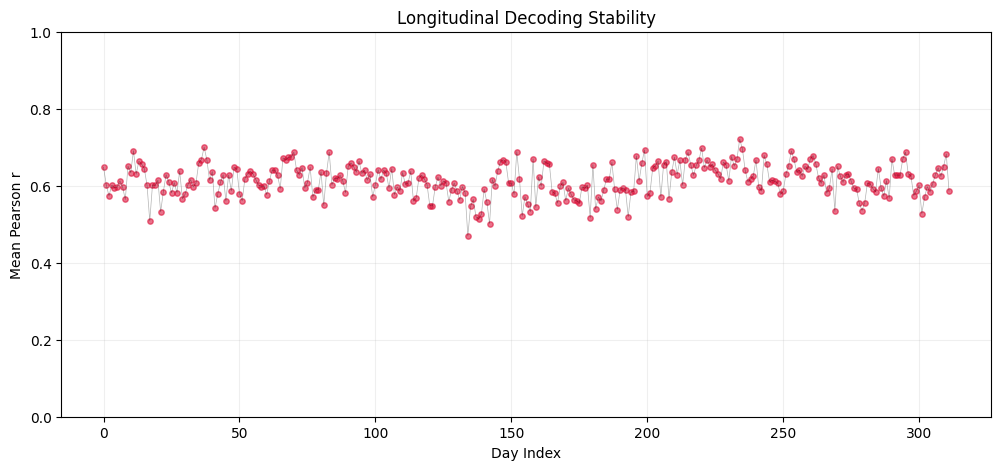

count    312.000000
mean       0.613398
std        0.041744
min        0.469552
25%        0.586334
50%        0.612777
75%        0.644494
max        0.721001
Name: r, dtype: float64


In [21]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def ridge_regression_gpu(X, Y, alpha=0.001):
    X_gpu = torch.as_tensor(X, dtype=torch.float32, device='cuda')
    Y_gpu = torch.as_tensor(Y, dtype=torch.float32, device='cuda')

    n_features = X_gpu.shape[1]
    XtX = X_gpu.t() @ X_gpu
    eye = torch.eye(n_features, device='cuda') * alpha

    weights = torch.linalg.solve(XtX + eye, X_gpu.t() @ Y_gpu)
    return weights

sweep_results = []
total_dates = len(dates)

for idx, date in enumerate(dates):
    try:
        data = load_day_custom(date, data_path)
        if data is None or len(data['sbp']) < 1000:
            continue

        X, Y = data['sbp'], data['finger_kinematics']

        split = int(0.8 * len(X))
        Xtr, Ytr = add_hist(X[:split], Y[:split], hist=20)
        Xte, Yte = add_hist(X[split:], Y[split:], hist=20)

        Xtr = np.column_stack([Xtr, np.ones(len(Xtr))])
        Xte = np.column_stack([Xte, np.ones(len(Xte))])

        W = ridge_regression_gpu(Xtr, Ytr, alpha=0.001)

        with torch.no_grad():
            Xte_gpu = torch.as_tensor(Xte, dtype=torch.float32, device='cuda')
            pred = (Xte_gpu @ W).cpu().numpy()

        rs = [pearsonr(Yte[:, i], pred[:, i])[0] for i in range(Yte.shape[1])]
        r_mean = np.mean(rs)

        sweep_results.append({'day': idx, 'r': r_mean})

        if idx % 20 == 0:
            print(f"Session {idx}/{total_dates} | r: {r_mean:.4f}")

    except Exception:
        continue

df = pd.DataFrame(sweep_results)
if not df.empty:
    plt.figure(figsize=(12, 5))
    plt.scatter(df['day'], df['r'], c='crimson', s=15, alpha=0.6)
    plt.plot(df['day'], df['r'], color='black', lw=0.5, alpha=0.3)
    plt.xlabel('Day Index')
    plt.ylabel('Mean Pearson r')
    plt.title('Longitudinal Decoding Stability')
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.2)
    plt.show()

    print(df['r'].describe())

### **Ridge Regression Cross day stability**




  0%|          | 0/312 [00:00<?, ?it/s]

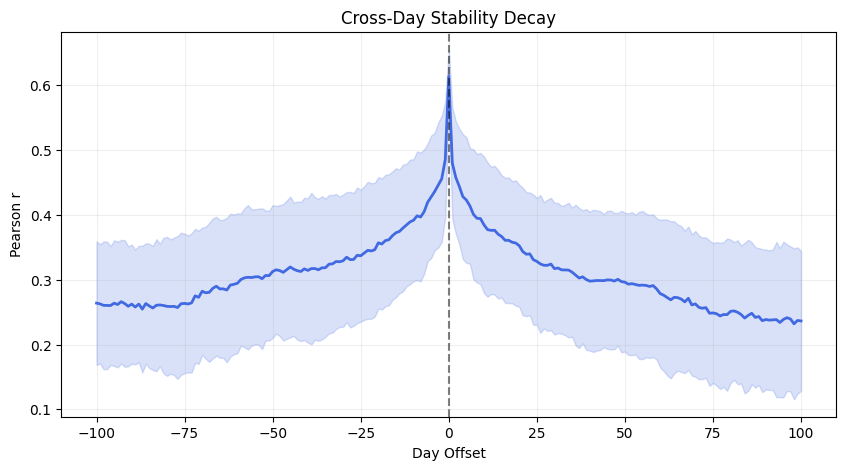

In [22]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from tqdm.auto import tqdm

def ridge_regression_gpu(X, Y, alpha=0.001):
    X_gpu = torch.as_tensor(X, dtype=torch.float32, device='cuda')
    Y_gpu = torch.as_tensor(Y, dtype=torch.float32, device='cuda')
    n_features = X_gpu.shape[1]
    XtX = X_gpu.t() @ X_gpu
    eye = torch.eye(n_features, device='cuda') * alpha
    return torch.linalg.solve(XtX + eye, X_gpu.t() @ Y_gpu)

trained_models = {}
test_data_cache = {}

for idx, date in enumerate(dates):
    try:
        data = load_day_custom(date, data_path)
        if data is None: continue

        X, Y = data['sbp'], data['finger_kinematics']
        split = int(0.8 * len(X))

        Xtr, Ytr = add_hist(X[:split], Y[:split], hist=20)
        Xtr = np.column_stack([Xtr, np.ones(len(Xtr))])

        Xte, Yte = add_hist(X[split:], Y[split:], hist=20)
        Xte = np.column_stack([Xte, np.ones(len(Xte))])

        trained_models[idx] = ridge_regression_gpu(Xtr, Ytr)
        test_data_cache[idx] = (torch.as_tensor(Xte, dtype=torch.float32, device='cuda'), Yte)
    except Exception:
        continue

cross_results = []
for train_idx, W in tqdm(trained_models.items()):
    for test_idx, (X_test_gpu, Y_test_cpu) in test_data_cache.items():
        diff = test_idx - train_idx
        if abs(diff) > 100: continue

        with torch.no_grad():
            pred = (X_test_gpu @ W).cpu().numpy()

        rs = [pearsonr(Y_test_cpu[:, i], pred[:, i])[0] for i in range(Y_test_cpu.shape[1])]
        cross_results.append({'diff': diff, 'r': np.mean(rs)})

df = pd.DataFrame(cross_results)
analysis = df.groupby('diff')['r'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(analysis['diff'], analysis['mean'], color='royalblue', lw=2)
plt.fill_between(analysis['diff'], analysis['mean'] - analysis['std'],
                 analysis['mean'] + analysis['std'], alpha=0.2, color='royalblue')
plt.axvline(0, color='black', ls='--', alpha=0.5)
plt.xlabel('Day Offset')
plt.ylabel('Pearson r')
plt.title('Cross-Day Stability Decay')
plt.grid(True, alpha=0.2)
plt.show()

## **LSTM Same day & Cross day stability**




In [23]:
import os
import pickle
import time
import random
import numpy as np
import torch
import torch.nn as nn
import warnings
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning, module='torch.nn.modules.rnn')


class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_size, num_states, num_layers, drop_prob=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.n_layers = num_layers
        actual_dropout = drop_prob if num_layers > 1 else 0

        self.lstm = nn.LSTM(input_dim, hidden_size, num_layers, batch_first=True, dropout=actual_dropout)
        self.fc = nn.Linear(hidden_size, num_states)
        self.h, self.c = None, None
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def forward(self, x, save_hidden_state=False, return_all_tsteps=False):
        if not save_hidden_state or self.h is None:
            self.init_hidden(x.shape[0])

        out, (h, c) = self.lstm(x, (self.h, self.c))

        if return_all_tsteps:
            out = self.fc(out)
        else:
            out = self.fc(out[:, -1])

        if save_hidden_state:
            self.h = h
            self.c = c
        return out

    def init_hidden(self, batch_size):
        self.h = torch.zeros(self.n_layers, batch_size, self.hidden_size).to(self.device)
        self.c = torch.zeros(self.n_layers, batch_size, self.hidden_size).to(self.device)


# UTILITIES


class FingerDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

def create_sequences(sbp_data, kin_data, seq_len):
    n_samples = len(sbp_data) - seq_len
    X_seq = np.zeros((n_samples, seq_len, sbp_data.shape[1]))
    Y_seq = np.zeros((n_samples, kin_data.shape[1]))
    for i in range(n_samples):
        X_seq[i] = sbp_data[i:i+seq_len]
        Y_seq[i] = kin_data[i+seq_len]
    return X_seq, Y_seq


data_folder = '/content/drive/My Drive/LINK_dataset/pkl_files'
model_folder = '/content/drive/My Drive/LINK_dataset/single_day_models'
checkpoint_file = os.path.join(model_folder, 'completed_sessions.txt')
os.makedirs(model_folder, exist_ok=True)

completed_dates = []
if os.path.exists(checkpoint_file):
    with open(checkpoint_file, 'r') as f:
        completed_dates = [line.strip() for line in f.readlines()]

NUM_CHANNELS, NUM_OUTPUTS = 96, 4
lstm_seq_len, lstm_hidden_size = 20, 300
lstm_num_layers = 1
lstm_batch_size, lstm_num_iterations = 64, 2000
learning_rate = 2e-4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
all_dates = sorted([f.replace('.pkl', '') for f in os.listdir(data_folder) if f.endswith('.pkl')])
total_sessions = len(all_dates)

print(f"Total Dataset Size: {total_sessions} sessions.")
print(f"Already Completed: {len(completed_dates)}")
print(f"Remaining to Run : {total_sessions - len(completed_dates)}\n")

for day_idx, date in enumerate(all_dates):
    if date in completed_dates:
        continue

    session_start = time.time()
    print(f" {'='*10} [ Session {day_idx + 1} of {total_sessions} ] {'='*10}")
    print(f" Target: {date}")
    fpath = os.path.join(data_folder, f'{date}.pkl')
    with open(fpath, 'rb') as f:
        data = pickle.load(f)


    X_all, Y_all = create_sequences(data['sbp'], data['finger_kinematics'], lstm_seq_len)
    split = int(0.8 * len(X_all))
    X_train, Y_train = X_all[:split], Y_all[:split]
    X_test, Y_test = X_all[split:], Y_all[split:]


    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train.reshape(-1, NUM_CHANNELS)).reshape(X_train.shape)
    X_test_scaled = scaler.transform(X_test.reshape(-1, NUM_CHANNELS)).reshape(X_test.shape)

    loader = DataLoader(FingerDataset(X_train_scaled, Y_train), batch_size=lstm_batch_size, shuffle=True, drop_last=True)

    model = LSTMModel(NUM_CHANNELS, lstm_hidden_size, NUM_OUTPUTS, lstm_num_layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    # TRAIN
    model.train()
    pbar = tqdm(total=lstm_num_iterations, desc=f" Training {date}", leave=False)
    it = 0
    while it < lstm_num_iterations:
        for bx, by in loader:
            if it >= lstm_num_iterations: break
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            it += 1
            pbar.update(1)
            pbar.set_postfix({"Loss": f"{loss.item():.4f}"})
    pbar.close()

    # EVALUATE
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
        y_pred = model(X_test_tensor).cpu().numpy()
        rs = [pearsonr(Y_test[:, i], y_pred[:, i])[0] for i in range(NUM_OUTPUTS)]
        mean_r = np.mean(rs)

    # SAVE MODEL
    torch.save(model.state_dict(), os.path.join(model_folder, f"{date}_lstm.pth"))

    # SAVE CHECKPOINT
    with open(checkpoint_file, 'a') as f:
        f.write(f"{date}\n")

    duration = time.time() - session_start
    print(f" [SUCCESS] Mean r: {mean_r:.4f} | Session Time: {duration:.1f}s\n")

print(f"\n Good code")

Total Dataset Size: 312 sessions.
Already Completed: 312
Remaining to Run : 0


 Good code


Pre-loading:   0%|          | 0/312 [00:00<?, ?it/s]

Models:   0%|          | 0/312 [00:00<?, ?it/s]

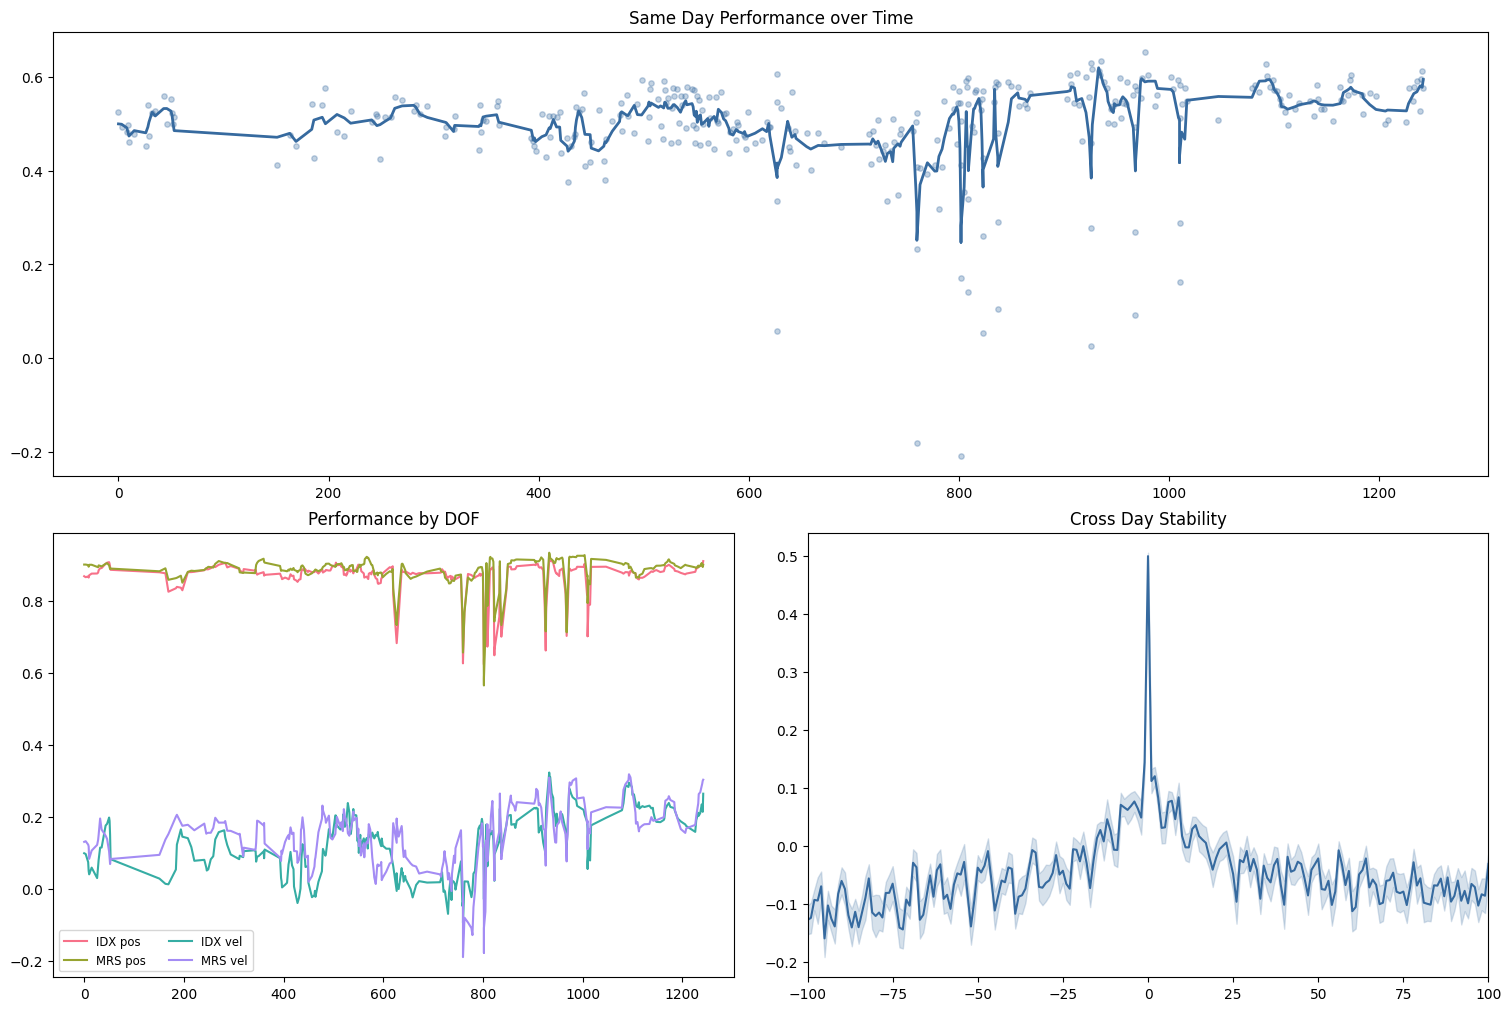

In [24]:
import os
import pickle
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
from datetime import datetime
from matplotlib.gridspec import GridSpec
import seaborn as sns

data_folder = '/content/drive/My Drive/LINK_dataset/pkl_files'
model_folder = '/content/drive/My Drive/LINK_dataset/single_day_models'
results_folder = '/content/drive/My Drive/LINK_dataset/results'
cache_folder = os.path.join(results_folder, 'tensor_cache')
os.makedirs(results_folder, exist_ok=True)
os.makedirs(cache_folder, exist_ok=True)

NUM_CHANNELS, NUM_OUTPUTS = 96, 4
lstm_seq_len, lstm_hidden_size = 20, 300
lstm_num_layers = 1
XLIM_ONESIDE = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_size, num_states, num_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.n_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_states)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def extract_date(filename):
    match = re.search(r'(\d{8})', filename)
    return datetime.strptime(match.group(1), '%Y%m%d') if match else None

def get_sequences_torch(sbp, kin, seq_len):
    sbp_t = torch.as_tensor(sbp, dtype=torch.float32)
    kin_t = torch.as_tensor(kin, dtype=torch.float32)
    X = sbp_t.unfold(0, seq_len, 1).transpose(1, 2)
    Y = kin_t[seq_len - 1:]
    min_len = min(X.size(0), Y.size(0))
    return X[:min_len], Y[:min_len]

def gpu_r2_score(y_true, y_pred):
    ss_res = torch.sum((y_true - y_pred) ** 2, dim=0)
    ss_tot = torch.sum((y_true - torch.mean(y_true, dim=0)) ** 2, dim=0)
    return 1 - ss_res / (ss_tot + 1e-8)

def run_pipeline():
    all_files = sorted([f for f in os.listdir(data_folder) if f.endswith('.pkl')])
    cpu_data_cache = {}
    csv_path = os.path.join(results_folder, 'lstm_results.csv')

    for f_name in tqdm(all_files, desc="Pre-loading"):
        cache_file = os.path.join(cache_folder, f_name.replace('.pkl', '.pt'))
        if os.path.exists(cache_file):
            tensors = torch.load(cache_file)
            if tensors[0].size(0) == tensors[1].size(0):
                cpu_data_cache[f_name] = tensors
                continue

        with open(os.path.join(data_folder, f_name), 'rb') as f:
            data = pickle.load(f)
            scaler = StandardScaler()
            sbp_scaled = scaler.fit_transform(data['sbp'])
            X, Y = get_sequences_torch(sbp_scaled, data['finger_kinematics'], lstm_seq_len)

            if X.size(0) != Y.size(0):
                raise RuntimeError(f"Alignment Error in {f_name}: X={X.size(0)}, Y={Y.size(0)}")

            tensors = (X, Y)
            torch.save(tensors, cache_file)
            cpu_data_cache[f_name] = tensors

    completed_models = set()
    if os.path.exists(csv_path):
        try:
            existing_df = pd.read_csv(csv_path)
            if not existing_df.empty and 'Train_day' in existing_df.columns:
                completed_models = set(existing_df['Train_day'].astype(str).unique())
        except Exception:
            pass

    for train_file in tqdm(all_files, desc="Models"):
        date_str = train_file.replace('.pkl', '')
        if date_str in completed_models:
            continue

        model_path = os.path.join(model_folder, f"{date_str}_lstm.pth")
        if not os.path.exists(model_path): continue

        train_dt = extract_date(train_file)
        model = LSTMModel(NUM_CHANNELS, lstm_hidden_size, NUM_OUTPUTS, lstm_num_layers).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()

        batch_results = []
        with torch.no_grad():
            for test_file in all_files:
                test_dt = extract_date(test_file)
                day_diff = (test_dt - train_dt).days
                if abs(day_diff) > XLIM_ONESIDE and day_diff != 0: continue

                X_test, Y_test = cpu_data_cache[test_file]
                preds = model(X_test.to(device))
                r2_dofs = gpu_r2_score(Y_test.to(device), preds)

                res = {
                    'Train_day': date_str, 'Test_day': test_file.replace('.pkl',''),
                    'Day_diff': day_diff, 'R2': r2_dofs.mean().item()
                }
                for i in range(NUM_OUTPUTS):
                    res[f'R2_DOF{i}'] = r2_dofs[i].item()
                batch_results.append(res)

        if batch_results:
            batch_df = pd.DataFrame(batch_results)
            batch_df.to_csv(csv_path, mode='a', index=False, header=not os.path.exists(csv_path))

        del model
        torch.cuda.empty_cache()

    return pd.read_csv(csv_path)

def plot_results(df):
    lstm_color = [54/255, 106/255, 159/255]
    dof_names = ["IDX pos", "MRS pos", "IDX vel", "MRS vel"]
    fig = plt.figure(figsize=(15, 10), layout='constrained')
    gs = GridSpec(2, 2, figure=fig)

    ax1 = fig.add_subplot(gs[0, :])
    sameday = df[df['Day_diff'] == 0].copy()
    sameday['dt'] = sameday['Train_day'].apply(extract_date)
    sameday = sameday.sort_values('dt')
    days_elapsed = (sameday['dt'] - sameday['dt'].min()).dt.days
    ax1.scatter(days_elapsed, sameday['R2'], color=lstm_color, s=15, alpha=0.3)
    ax1.plot(days_elapsed, sameday['R2'].rolling(5, center=True, min_periods=1).mean(), color=lstm_color, lw=2)
    ax1.set_title("Same Day Performance over Time")

    ax2 = fig.add_subplot(gs[1, 0])
    colors = sns.color_palette("husl", 4)
    for i in range(4):
        ax2.plot(days_elapsed, sameday[f'R2_DOF{i}'].rolling(5, center=True, min_periods=1).mean(), color=colors[i], label=dof_names[i])
    ax2.set_title("Performance by DOF")
    ax2.legend(fontsize='small', ncol=2)

    ax3 = fig.add_subplot(gs[1, 1])
    decay = df.groupby('Day_diff')['R2'].agg(['mean', 'std', 'count']).reset_index()
    x, y = decay['Day_diff'], decay['mean']
    err = decay['std'] / np.sqrt(decay['count'])
    ax3.plot(x, y, color=lstm_color)
    ax3.fill_between(x, y-err, y+err, color=lstm_color, alpha=0.2)
    ax3.set_xlim(-XLIM_ONESIDE, XLIM_ONESIDE)
    ax3.set_title("Cross Day Stability")
    plt.show()

results_df = run_pipeline()
plot_results(results_df)